# **Persistance**

In [26]:
from dotenv import load_dotenv
load_dotenv()
import os
from langchain_huggingface import ChatHuggingFace,HuggingFaceEndpoint
from langgraph.graph import StateGraph,START,END
from langgraph.checkpoint.memory import InMemorySaver
from typing import TypedDict
from langchain_core.prompts import ChatPromptTemplate
from IPython.display import Image, display

if os.getenv("HUGGINGFACEHUB_API_TOKEN") is None:
    raise ValueError("HUGGINGFACEHUB_API_TOKEN environment variable not set")

In [27]:
model = HuggingFaceEndpoint(
    repo_id="deepseek-ai/DeepSeek-V4-Pro",
    task="text-generation",
    max_new_tokens=512,
    do_sample=False,
    repetition_penalty=1.03,
    temperature=0.7
)

chat = ChatHuggingFace(llm=model, verbose=True)

In [28]:
class Joke(TypedDict):
    topic: str
    joke: str
    explanation: str

In [29]:
def generate_joke(state: Joke) -> Joke:
    prompt = ChatPromptTemplate.from_messages([
        ("system", "You are a joke generator. You generate jokes based on the given topic only. Do not include any explanations or additional text."),
        ("user", "Generate a joke about {topic}"),
    ])

    chain = prompt | chat
    result = chain.invoke({"topic": state["topic"]})
    return {"topic": state["topic"], "joke": result.content}


In [30]:
def explain_joke(state: Joke) -> Joke:
    prompt = ChatPromptTemplate.from_messages([
        ("system", "You are a joke explainer. You explain jokes based on the given joke and topic."),
        ("user", "Explain the joke about {topic}: {joke}"),
    ])

    chain = prompt | chat
    result = chain.invoke({"topic": state["topic"], "joke": state["joke"]})
    return {"topic": state["topic"], "joke": state["joke"], "explanation": result.content}

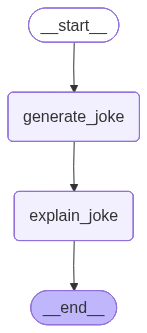

In [31]:
graph = StateGraph(Joke)
graph.add_node("generate_joke", generate_joke)
graph.add_node("explain_joke", explain_joke)
graph.add_edge(START, "generate_joke")
graph.add_edge("generate_joke", "explain_joke")
graph.add_edge("explain_joke", END)

checkpointer = InMemorySaver()
builder = graph.compile(checkpointer=checkpointer)
display(Image(builder.get_graph(xray=True).draw_mermaid_png()))

In [32]:
config = {"configurable": {"thread_id": "1"}}
builder.invoke({"topic": "programming"}, config=config)

{'topic': 'programming',
 'joke': 'Why do programmers prefer dark mode?\n\nBecause light attracts bugs.',
 'explanation': 'This joke is a pun that plays on the double meaning of the word "bugs":\n\n- In everyday language, bugs are insects, and many insects are attracted to light. So if you work in a bright environment ("light mode"), you might attract literal bugs.\n- In programming, a "bug" is an error or flaw in the code that causes it to behave unexpectedly.\n\nThe punchline "Because light attracts bugs" humorously suggests that using a light-themed interface (light mode) will draw software bugs to your code, while dark mode helps keep them away. It’s a playful twist that combines the real-world behavior of insects with the programmer’s eternal struggle against coding errors.'}

In [33]:
config2 = {"configurable": {"thread_id": "2"}}
builder.invoke({"topic": "girlfriend"}, config=config2)

{'topic': 'girlfriend',
 'joke': 'Why did the girlfriend bring a ladder to the bar?  \nBecause she heard the drinks were on the house and she wanted to check the roof for any hidden exes.',
 'explanation': 'We need to explain the joke: "Why did the girlfriend bring a ladder to the bar? Because she heard the drinks were on the house and she wanted to check the roof for any hidden exes."\n\nThe joke plays on two puns/idioms:\n1. "Drinks are on the house" means the bar is offering free drinks, paid for by the establishment. "On the house" literally sounds like the drinks are physically located on top of the house (the roof).\n2. "Exes" sounds like "X\'s" (like ex-boyfriends/girlfriends) but also could be interpreted as "exits" or something? Wait, "check the roof for any hidden exes" – the girlfriend, hearing "drinks are on the house," takes it literally and brings a ladder to get onto the roof to get the drinks. But then the punchline adds: "she wanted to check the roof for any hidden exe

In [34]:
list(builder.get_state_history(config))

[StateSnapshot(values={'topic': 'programming', 'joke': 'Why do programmers prefer dark mode?\n\nBecause light attracts bugs.', 'explanation': 'This joke is a pun that plays on the double meaning of the word "bugs":\n\n- In everyday language, bugs are insects, and many insects are attracted to light. So if you work in a bright environment ("light mode"), you might attract literal bugs.\n- In programming, a "bug" is an error or flaw in the code that causes it to behave unexpectedly.\n\nThe punchline "Because light attracts bugs" humorously suggests that using a light-themed interface (light mode) will draw software bugs to your code, while dark mode helps keep them away. It’s a playful twist that combines the real-world behavior of insects with the programmer’s eternal struggle against coding errors.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f162f51-d518-6772-8002-234668c4d2d2'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, 

In [35]:
list(builder.get_state_history(config2))

[StateSnapshot(values={'topic': 'girlfriend', 'joke': 'Why did the girlfriend bring a ladder to the bar?  \nBecause she heard the drinks were on the house and she wanted to check the roof for any hidden exes.', 'explanation': 'We need to explain the joke: "Why did the girlfriend bring a ladder to the bar? Because she heard the drinks were on the house and she wanted to check the roof for any hidden exes."\n\nThe joke plays on two puns/idioms:\n1. "Drinks are on the house" means the bar is offering free drinks, paid for by the establishment. "On the house" literally sounds like the drinks are physically located on top of the house (the roof).\n2. "Exes" sounds like "X\'s" (like ex-boyfriends/girlfriends) but also could be interpreted as "exits" or something? Wait, "check the roof for any hidden exes" – the girlfriend, hearing "drinks are on the house," takes it literally and brings a ladder to get onto the roof to get the drinks. But then the punchline adds: "she wanted to check the roo

## Updating the State

In [36]:
builder.update_state({"configurable": {"thread_id": "2", 'checkpoint_id': '1f162f31-f208-6f47-8000-7d935ff44047'}}, {"topic": "dogs"})

{'configurable': {'thread_id': '2',
  'checkpoint_ns': '',
  'checkpoint_id': '1f162f52-b626-6c02-8000-5b9de3053e94'}}

In [38]:
list(builder.get_state_history(config2))

[StateSnapshot(values={'topic': 'dogs'}, next=('generate_joke',), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f162f52-b626-6c02-8000-5b9de3053e94'}}, metadata={'source': 'update', 'step': 0, 'parents': {}}, created_at='2026-06-08T04:47:35.957597+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f162f31-f208-6f47-8000-7d935ff44047'}}, tasks=(PregelTask(id='44f072d9-f374-2484-d617-5b07d62b86ca', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'girlfriend', 'joke': 'Why did the girlfriend bring a ladder to the bar?  \nBecause she heard the drinks were on the house and she wanted to check the roof for any hidden exes.', 'explanation': 'We need to explain the joke: "Why did the girlfriend bring a ladder to the bar? Because she heard the drinks were on the house and she wanted to check the 

In [39]:
builder.invoke(None, {"configurable": {"thread_id": "2", 'checkpoint_id': '1f162f52-b626-6c02-8000-5b9de3053e94'}})

{'topic': 'dogs',
 'joke': 'Why do dogs always race to the door when the doorbell rings?  \nBecause they can’t figure out who let the dogs out.',
 'explanation': 'This joke is a playful twist on the classic dog behavior of sprinting to the door when the bell rings, combined with the iconic (and endlessly catchy) song “Who Let the Dogs Out?” by Baha Men.\n\nHere’s the breakdown:  \n- **Setup**: We all know dogs go bonkers when the doorbell rings—they race to see who’s there, barking up a storm.  \n- **Punchline**: The joke imagines that dogs aren’t just excited; they’re genuinely trying to solve the mystery posed by the song. They hear the doorbell, think someone might be arriving to let them out (or in), but they’re still stuck on that eternal question: “Who let the dogs out?” So they rush to the door hoping to finally get an answer.  \n\nIt’s a silly bit of wordplay that gives dogs a human-like curiosity, turning their everyday chaos into a punny, musical misunderstanding.'}

In [40]:
list(builder.get_state_history(config2))

[StateSnapshot(values={'topic': 'dogs', 'joke': 'Why do dogs always race to the door when the doorbell rings?  \nBecause they can’t figure out who let the dogs out.', 'explanation': 'This joke is a playful twist on the classic dog behavior of sprinting to the door when the bell rings, combined with the iconic (and endlessly catchy) song “Who Let the Dogs Out?” by Baha Men.\n\nHere’s the breakdown:  \n- **Setup**: We all know dogs go bonkers when the doorbell rings—they race to see who’s there, barking up a storm.  \n- **Punchline**: The joke imagines that dogs aren’t just excited; they’re genuinely trying to solve the mystery posed by the song. They hear the doorbell, think someone might be arriving to let them out (or in), but they’re still stuck on that eternal question: “Who let the dogs out?” So they rush to the door hoping to finally get an answer.  \n\nIt’s a silly bit of wordplay that gives dogs a human-like curiosity, turning their everyday chaos into a punny, musical misunders